# Binding Event Analysis and Residence Time Characterization (Fasudil)

This notebook identifies and analyzes **binding events between Fasudil and α-synuclein** using residue-wise protein–ligand distance/contact traces from molecular dynamics trajectories.

---

## Context within the workflow

This analysis complements the PCA and MSM/PCCA workflows:

- **PCA** identifies structural binding-mode clusters.
- **MSM/PCCA** identifies kinetically relevant metastable states.
- **Binding-event analysis** directly quantifies how long the ligand remains continuously associated with specific residues.

Rather than relying on clustered states, this notebook works directly along the trajectory time axis to detect continuous bound segments and estimate residence times.

---

## Workflow overview

1. Load the precomputed Fasudil distance/contact matrix.
2. Define a distance-based binding criterion.
3. Identify continuous residue-wise binding events.
4. Calculate residence times as the number of consecutive bound frames.
5. Extract the longest and second-longest residence events per residue.
6. Visualize residue-wise residence-time patterns.

---

## Goal

The goal is to determine whether Fasudil shows long-lived residue-specific binding events, and to compare its residence-time behavior against Ligand-47. In the broader project, this helps test whether Fasudil lacks the persistent, metastable binding behavior observed for Ligand-47.


## Importing analysis libraries

This cell imports the scientific Python libraries used for trajectory analysis, numerical processing, plotting, and information-theoretic calculations. It also widens the notebook display area to make plots and tables easier to inspect.


In [4]:
from __future__ import print_function, division
import mdtraj as md
from mdtraj.utils import ensure_type
from mdtraj.geometry import compute_distances, compute_angles
from mdtraj.geometry import _geometry
import os
import sys
import numpy as np
import pandas as pd
import scipy 
from scipy import optimize
from scipy.optimize import leastsq
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
import math
import itertools 
import pickle
from numpy import log2, zeros, mean, var, sum, loadtxt, arange, array, cumsum, dot, transpose, diagonal, floor
from numpy.linalg import inv, lstsq
import pyblock
from mdtraj.geometry import _geometry
from mdtraj.utils import ensure_type
from mdtraj.geometry import compute_distances, compute_angles
from scipy.stats import pearsonr
#from matplotlib import 

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import pyinform

## Defining binding-event detection utilities

This cell defines helper functions for identifying continuous binding events from frame-wise distance/contact data. A frame is classified as bound when the specified interaction criterion is satisfied, and consecutive bound frames are grouped into individual residence events.


In [5]:
# Identifies contiguous stretches of frames where the ligand satisfies the binding condition.
def residence_events(data:np.ndarray, condition:"a python function that returns true when a condition on data is met")->list:
    """returns a list of numpy arrays containing the indices (of the zeroth dim) of data where a condition is met contiguously"""
    idx = np.arange(len(data))
    bools = condition(data).astype(int)
    comp = np.stack([idx,bools],axis = 1)
    return [i[:,0][1:] if len(i)>1 else i[:,0] for i in filter(lambda x:any(x[:,1]!=0),np.split(comp,np.where(comp[:,1]==0)[0]))]

#example of a really simple condition one could place on data if it is a 1 dimensional array
#the array doesn't have to be one dimensional, and you can add as many conditions as you want so long as the output
#is a bool array the same length as the zeroth dimension of the input

#as an example, we'll use the following array for data argument
#data = np.array([1,0,0,0,1,1,1,0,1,1,1,0,0,0,1,0,1,1,1,1,1,])
#and a simple condition
# Defines the contact-based criterion used to classify frames as bound or unbound.
def condition(x):
    return 0<np.where(x<.6,1,0).sum(1)

## Loading the Fasudil distance matrix

This cell loads the precomputed protein–ligand distance matrix for Fasudil. The matrix is used to determine whether Fasudil is within the binding/contact cutoff for each residue across the trajectory.


In [6]:
dmat = np.load("/data/asn/tica/fasudil/dist/distance_matrix_fulL_FAS.npy")

## Computing residue-wise residence events

This cell analyzes each residue-specific distance trace separately. For each residue, it identifies continuous binding events and stores the corresponding residence times, sorted from longest to shortest.

**Note:** This notebook is the Fasudil version of the binding-event analysis. If the first line still references `dmat_lig_47`, it should be changed to `dmat` so that all residence times are calculated from the Fasudil distance matrix.


In [11]:
dmat_1 = dmat_lig_47[:, :1]
events_1 = residence_events(dmat_1,condition)
residence_time_1 = np.sort(np.array([len(i) for i in events_1]))[::-1]

dmat_2 = dmat[:, 1:2]
events_2 = residence_events(dmat_2,condition)
residence_time_2 = np.sort(np.array([len(i) for i in events_2]))[::-1]

dmat_3 = dmat[:, 2:3]
events_3 = residence_events(dmat_3,condition)
residence_time_3 = np.sort(np.array([len(i) for i in events_3]))[::-1]

dmat_4 = dmat[:, 3:4]
events_4 = residence_events(dmat_4,condition)
residence_time_4 = np.sort(np.array([len(i) for i in events_4]))[::-1]

dmat_5 = dmat[:, 4:5]
events_5 = residence_events(dmat_5,condition)
residence_time_5 = np.sort(np.array([len(i) for i in events_5]))[::-1]

dmat_6 = dmat[:, 5:6]
events_6 = residence_events(dmat_6,condition)
residence_time_6 = np.sort(np.array([len(i) for i in events_6]))[::-1]

dmat_7 = dmat[:, 6:7]
events_7 = residence_events(dmat_7,condition)
residence_time_7 = np.sort(np.array([len(i) for i in events_7]))[::-1]

dmat_8 = dmat[:, 7:8]
events_8 = residence_events(dmat_8,condition)
residence_time_8 = np.sort(np.array([len(i) for i in events_8]))[::-1]

dmat_9 = dmat[:, 8:9]
events_9 = residence_events(dmat_9,condition)
residence_time_9 = np.sort(np.array([len(i) for i in events_9]))[::-1]

dmat_10 = dmat[:, 9:10]
events_10 = residence_events(dmat_10,condition)
residence_time_10 = np.sort(np.array([len(i) for i in events_10]))[::-1]

dmat_11 = dmat[:, 10:11]
events_11 = residence_events(dmat_11,condition)
residence_time_11 = np.sort(np.array([len(i) for i in events_11]))[::-1]

dmat_12 = dmat[:, 11:12]
events_12 = residence_events(dmat_12,condition)
residence_time_12 = np.sort(np.array([len(i) for i in events_12]))[::-1]

dmat_13 = dmat[:, 12:13]
events_13 = residence_events(dmat_13,condition)
residence_time_13 = np.sort(np.array([len(i) for i in events_13]))[::-1]

dmat_14 = dmat[:, 13:14]
events_14 = residence_events(dmat_14,condition)
residence_time_14 = np.sort(np.array([len(i) for i in events_14]))[::-1]

dmat_15 = dmat[:, 14:15]
events_15 = residence_events(dmat_15,condition)
residence_time_15 = np.sort(np.array([len(i) for i in events_15]))[::-1]

dmat_16 = dmat[:, 15:16]
events_16 = residence_events(dmat_16,condition)
residence_time_16 = np.sort(np.array([len(i) for i in events_16]))[::-1]

dmat_17 = dmat[:, 16:17]
events_17 = residence_events(dmat_17,condition)
residence_time_17 = np.sort(np.array([len(i) for i in events_17]))[::-1]

dmat_18 = dmat[:, 17:18]
events_18 = residence_events(dmat_18,condition)
residence_time_18 = np.sort(np.array([len(i) for i in events_18]))[::-1]

dmat_19 = dmat[:, 18:19]
events_19 = residence_events(dmat_19,condition)
residence_time_19 = np.sort(np.array([len(i) for i in events_19]))[::-1]

dmat_20 = dmat[:, 19:20]
events_20 = residence_events(dmat_20,condition)
residence_time_20 = np.sort(np.array([len(i) for i in events_20]))[::-1]

## Defining a plotting helper for residence-time summaries

This cell defines a reusable bar-plotting function for comparing the longest and second-longest residence events across residues.


In [27]:
# Creates an overlapped bar plot for comparing residence-time summaries across residues.
def overlapped_bar(df, show=False, width=0.9, alpha=.5,
                   title='', xticks='', yticks= '', xlabel='', ylabel='', **plot_kwargs):
    """Like a stacked bar chart except bars on top of each other with transparency"""
    #xlabel = xlabel or df.index.name
    N = len(df)
    M = len(df.columns)
    indices = np.arange(N)
    colors = ['steelblue', 'firebrick', 'darksage', 'goldenrod', 'gray'] * int(M / 5. + 1)
    for i, label, color in zip(range(M), df.columns, colors):
        kwargs = plot_kwargs
        kwargs.update({'color': color, 'label': label})
        plt.bar(indices, df[label], width=width, alpha=alpha if i else 1, **kwargs)
        plt.xticks(indices + .5 * width,
                   ['{}'.format(idx) for idx in df.index.values])
    plt.legend()
    plt.xticks
    plt.yticks
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    if show:
        plt.show()
    return plt.gcf()

## Extracting the longest residence event per residue

This cell collects the maximum residence time for each residue. These values represent the longest continuous Fasudil-binding event observed for each residue-specific interaction trace.


In [28]:
high = [residence_time_1[0], residence_time_2[0], residence_time_3[0], residence_time_4[0], residence_time_5[0] ,residence_time_6[0],residence_time_7[0], residence_time_8[0], residence_time_9[0], residence_time_10[0], residence_time_11[0], residence_time_12[0], residence_time_13[0], residence_time_14[0], residence_time_15[0], residence_time_16[0], residence_time_17[0], residence_time_18[0], residence_time_19[0], residence_time_20[0]]

## Inspecting longest residence times

This cell displays the list of longest residence events across the selected residues.


In [29]:
high

[489,
 830,
 835,
 836,
 801,
 787,
 848,
 840,
 844,
 776,
 771,
 770,
 756,
 1660,
 1708,
 1708,
 1185,
 793,
 955,
 717]

## Extracting the second-longest residence event per residue

This cell collects the second-longest residence time for each residue, providing a comparison against the dominant binding event and helping distinguish isolated long events from repeated persistent binding.


In [30]:
low = [residence_time_1[1], residence_time_2[1], residence_time_3[1], residence_time_4[1], residence_time_5[1] ,residence_time_6[1],residence_time_7[1], residence_time_8[1], residence_time_9[1], residence_time_10[1], residence_time_11[1], residence_time_12[1], residence_time_13[1], residence_time_14[1], residence_time_15[1], residence_time_16[1], residence_time_17[1], residence_time_18[1], residence_time_19[1], residence_time_20[1]]

## Inspecting second-longest residence times

This cell displays the list of second-longest residence events across the selected residues.


In [31]:
low

[293,
 649,
 551,
 766,
 799,
 648,
 619,
 479,
 787,
 576,
 553,
 440,
 755,
 1157,
 1238,
 1195,
 815,
 718,
 725,
 423]

## Preparing residence-time data for plotting

This cell defines the residue labels and organizes the longest and second-longest residence times into a dataframe for visualization.


In [32]:
#low = [1000.95, 1233.37, 1198.97, 1198.01, 1214.29, 1130.86, 1138.70, 1104.12, 1012.95, 1000.36]
res_ = ('D','N','E','A','Y','E','M','P','S','E','E','G','Y','Q','D','Y','E','P','E','A')
#high = [1184.53, 1523.48, 1521.05, 1517.88, 1519.88, 1414.98, 1419.34, 1415.13, 1182.70, 1165.17]
df = pd.DataFrame(np.matrix([high, low]).T, columns=['High', 'Low'],
                  index=pd.Index(['T%s' %i for i in range(len(high))],
                  name='Index'))
#overlapped_bar(df, xticks= res_, show=False)

## Visualizing residue-wise Fasudil residence times

This cell generates a bar plot comparing the longest and second-longest binding events for each residue. The resulting plot summarizes which residues sustain the longest Fasudil interactions.


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


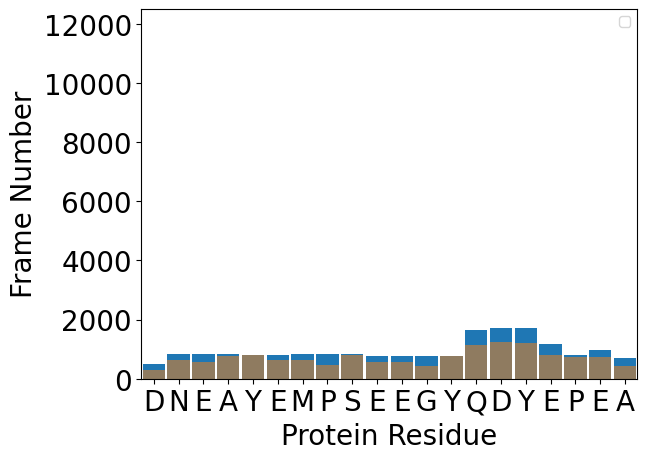

In [36]:
N = len(df)
M = len(df.columns)
indices = np.arange(N)
colors = ['steelblue', 'firebrick', 'darksage', 'goldenrod', 'gray'] * int(M / 5. + 1)
for i, label, color in zip(range(M), df.columns, colors):
    #kwargs = plot_kwargs
    #kwargs.update({'color': color, 'label': label})
    plt.bar(indices, df[label], width=0.9, alpha=.5 if i else 1)
    plt.xticks(indices + .5 * 0.9,
                   ['{}'.format(idx) for idx in df.index.values])
plt.legend()
plt.xticks([0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19],res_, fontsize=20)
plt.yticks(fontsize=20)
plt.xlim(-0.5,19.5)
plt.ylim(0,12500)
#plt.title(title)
plt.xlabel('Protein Residue', fontsize=20)
plt.ylabel('Frame Number', fontsize=20)
plt.show()